# 02 – Diffusion Models: a tiny, real, from-scratch DDPM

This notebook trains a REAL (small) denoising-diffusion model on the **same toy 2D 8-mode ring**
dataset that `01-gans/01-gans.ipynb` used — actually executed, no fabricated output — so its results
can be compared directly against that notebook's GAN results.

It reuses the 5-step PyTorch training-loop pattern from
`09-pytorch/02-nn-module-and-training-loop` (forward → loss → `.backward()` → `optimizer.step()` →
`zero_grad()`), applied to a single denoising `nn.Module` instead of GANs' two adversarial networks —
exactly the "simpler, more stable objective" motivation from `notes.md`'s Problem section.

See `notes.md` for the full derivation of the forward/reverse process and the simplified
noise-prediction objective.


In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Tiny models on CPU: force single-threaded BLAS so PyTorch doesn't oversubscribe
# threads for matrices this small (same fix `01-gans/01-gans.ipynb` needed — an
# untuned run of tiny matmuls otherwise suffers severe thread-oversubscription slowdown).
torch.set_num_threads(1)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)


## 1. The toy 2D distribution — identical to `01-gans/01-gans.ipynb`

Same `sample_real` function, same seed-0 usage pattern, same 8-mode Gaussian ring: this is
deliberate, so every statistic below (mean, std, nearest-mode distance) can be compared apples-to-
apples against the GAN topic's numbers.


real sample mean: [-0.02279891  0.06202313]
real sample std:  [1.4356362 1.3915142]


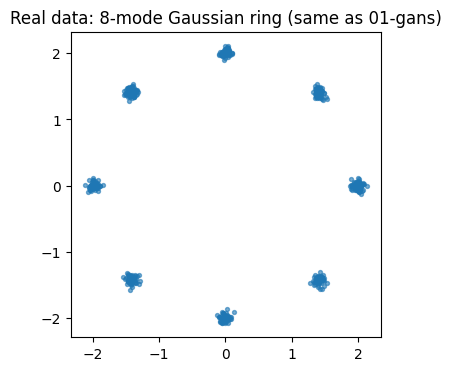

In [2]:
def sample_real(n):
    angles = np.random.choice(8, size=n) * (2 * np.pi / 8)
    radius = 2.0
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    noise = np.random.randn(n, 2) * 0.05
    return torch.tensor(centers + noise, dtype=torch.float32)

real_sample = sample_real(500)
print("real sample mean:", real_sample.mean(0).numpy())
print("real sample std: ", real_sample.std(0).numpy())

plt.figure(figsize=(4, 4))
plt.scatter(real_sample[:, 0], real_sample[:, 1], s=8, alpha=0.6)
plt.title("Real data: 8-mode Gaussian ring (same as 01-gans)")
plt.gca().set_aspect("equal")
plt.show()


## 2. Forward diffusion process — closed form $q(x_t \mid x_0)$

`notes.md`'s Mathematical foundation derives, via the reparameterization trick, that diffusing
$x_0$ for $t$ steps under a fixed noise schedule $\beta_1, \dots, \beta_T$ has the closed form

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon, \qquad \epsilon \sim \mathcal N(0, I)$$

where $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s=1}^t \alpha_s$ — meaning *any* intermediate
noisy version of $x_0$ can be sampled in **one shot**, without simulating all $t$ intermediate steps.
`beta_end=0.2` over `T=40` steps was chosen (checked numerically below) so that $\bar\alpha_T$ is
close enough to 0 that $x_T$ is visually indistinguishable from pure Gaussian noise — the forward
process must actually destroy all structure by step $T$ for the reverse process (trained only on
these forward samples) to have any chance of starting from pure noise at sampling time.


In [3]:
def make_schedule(T, beta_end, beta_start=1e-4):
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars

def q_sample(x0, t_idx, alpha_bars, noise):
    # Closed-form one-shot forward diffusion: x_t = sqrt(ab_t) x0 + sqrt(1-ab_t) eps.
    ab = alpha_bars[t_idx].unsqueeze(1)
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise

T_MAIN, BETA_END_MAIN = 40, 0.2
betas, alphas, alpha_bars = make_schedule(T_MAIN, BETA_END_MAIN)
print(f"alpha_bar_1={alpha_bars[0]:.4f}  alpha_bar_{T_MAIN}={alpha_bars[-1]:.6f}"
      f"  sqrt(1-alpha_bar_{T_MAIN})={torch.sqrt(1-alpha_bars[-1]):.4f}")


alpha_bar_1=0.9999  alpha_bar_40=0.013522  sqrt(1-alpha_bar_40)=0.9932


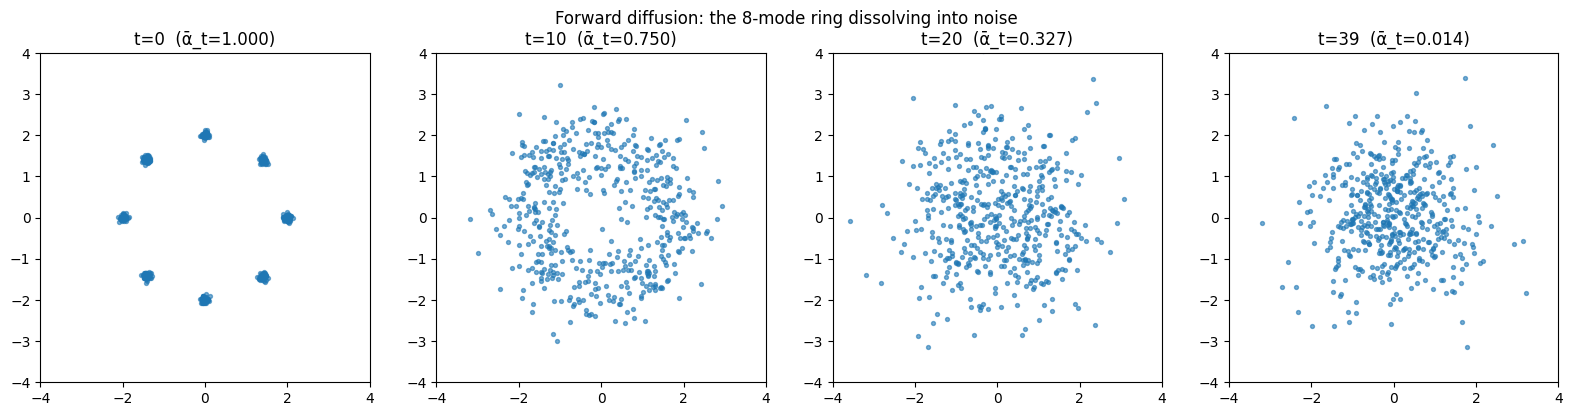

In [4]:
# Visualize the forward process on the SAME 500 real points at several t values.
fixed_x0 = real_sample
fixed_noise = torch.randn_like(fixed_x0)
checkpoints = [0, T_MAIN // 4, T_MAIN // 2, T_MAIN - 1]

fig, axes = plt.subplots(1, len(checkpoints), figsize=(4 * len(checkpoints), 4))
for ax, t in zip(axes, checkpoints):
    t_idx = torch.full((fixed_x0.shape[0],), t, dtype=torch.long)
    x_t = q_sample(fixed_x0, t_idx, alpha_bars, fixed_noise)
    ax.scatter(x_t[:, 0], x_t[:, 1], s=8, alpha=0.6)
    ax.set_title(f"t={t}  (ᾱ_t={alpha_bars[t]:.3f})")
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.suptitle("Forward diffusion: the 8-mode ring dissolving into noise")
plt.tight_layout()
plt.show()


By `t=T-1` the ring structure is visually gone — this is the pure-noise endpoint the reverse
process (below) starts sampling from.

## 3. Denoising network — a tiny `nn.Module`, same pattern as `09-pytorch`/`01-gans`

The network takes the noisy point $x_t \in \mathbb R^2$ **and** the timestep (as a scalar fraction
$t/T \in [0,1]$, concatenated as a third input feature — no fancy sinusoidal embedding needed at
this toy scale) and predicts the noise $\epsilon$ that was added. This is the "simplified
noise-prediction objective" from `notes.md`: a single, ordinary regression network with an ordinary
MSE loss — no adversary, no second network, no alternating optimizers.


In [5]:
class DenoiseNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t_frac):
        # x: (batch, 2), t_frac: (batch, 1) in [0, 1]
        return self.net(torch.cat([x, t_frac], dim=1))


## 4. Training loop — the exact `09-pytorch` 5-step pattern

Per step: sample a batch of real $x_0$, a random timestep $t$ per example, and noise $\epsilon$;
build $x_t$ via the one-shot closed form above; predict $\hat\epsilon = \text{model}(x_t, t/T)$;
minimize $\lVert \hat\epsilon - \epsilon \rVert^2$ (ordinary MSE — no min-max game, no second
network's loss to balance against). forward → loss → `.backward()` → `optimizer.step()` →
`zero_grad()`, unchanged from `09-pytorch/02-nn-module-and-training-loop`.


In [6]:
def train_diffusion(T, beta_end, steps=3000, batch=128, lr=1e-3, hidden=64, seed=0, verbose=True):
    torch.manual_seed(seed)
    betas, alphas, alpha_bars = make_schedule(T, beta_end)
    model = DenoiseNet(hidden=hidden)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t0 = time.time()
    log = []
    for step in range(steps):
        x0 = sample_real(batch)
        t_idx = torch.randint(0, T, (batch,))
        noise = torch.randn(batch, 2)
        x_t = q_sample(x0, t_idx, alpha_bars, noise)
        t_frac = (t_idx.float() / T).unsqueeze(1)

        pred = model(x_t, t_frac)               # forward
        loss = ((pred - noise) ** 2).mean()      # loss (MSE noise-prediction)
        opt.zero_grad()
        loss.backward()                          # backward
        opt.step()                               # optimizer.step()

        if verbose and (step % (steps // 5) == 0 or step == steps - 1):
            log.append((step, loss.item()))
    elapsed = time.time() - t0
    return model, (betas, alphas, alpha_bars), log, elapsed

model, (betas, alphas, alpha_bars), log, elapsed = train_diffusion(T_MAIN, BETA_END_MAIN, steps=3000)
for step, l in log:
    print(f"step {step:5d}  noise-prediction MSE loss = {l:.4f}")
print(f"training time: {elapsed:.2f}s for 3000 steps, T={T_MAIN}")


step     0  noise-prediction MSE loss = 1.0135
step   600  noise-prediction MSE loss = 0.4261
step  1200  noise-prediction MSE loss = 0.3753
step  1800  noise-prediction MSE loss = 0.4480
step  2400  noise-prediction MSE loss = 0.3614
step  2999  noise-prediction MSE loss = 0.3497
training time: 1.43s for 3000 steps, T=40


Notice the loss decreases roughly monotonically (unlike `01-gans`'s oscillating $D$/$G$ losses)
— exactly the stability difference `notes.md`'s Why-simpler-fails section argues for: this is
ordinary single-network MSE regression, not a two-player game.

## 5. Reverse process — sampling from pure noise

`notes.md` derives the reverse (ancestral/DDPM) sampling step from the trained noise predictor:
starting at $x_T \sim \mathcal N(0, I)$, for $t = T, \dots, 1$:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\hat\epsilon_\theta(x_t, t)\right) + \sqrt{\beta_t}\, z, \qquad z \sim \mathcal N(0, I) \text{ if } t>1 \text{ else } 0$$


In [7]:
@torch.no_grad()
def reverse_sample(model, T, betas, alphas, alpha_bars, n=500, seed=1):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, 2, generator=g)
    for t in reversed(range(T)):
        t_frac = torch.full((n, 1), t / T)
        eps_hat = model(x, t_frac)
        beta_t, alpha_t, ab_t = betas[t], alphas[t], alpha_bars[t]
        mean = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1 - ab_t)) * eps_hat)
        if t > 0:
            z = torch.randn(n, 2, generator=g)
            x = mean + torch.sqrt(beta_t) * z
        else:
            x = mean
    return x

untrained_model = DenoiseNet(hidden=64)
before = reverse_sample(untrained_model, T_MAIN, betas, alphas, alpha_bars, n=500, seed=1)

t0 = time.time()
after = reverse_sample(model, T_MAIN, betas, alphas, alpha_bars, n=500, seed=1)
sample_time_main = time.time() - t0

print("real sample:               mean=%s  std=%s" % (real_sample.mean(0).numpy(), real_sample.std(0).numpy()))
print("generated, untrained model: mean=%s  std=%s" % (before.mean(0).numpy(), before.std(0).numpy()))
print("generated, trained model:   mean=%s  std=%s" % (after.mean(0).numpy(), after.std(0).numpy()))
print(f"sampling time (T={T_MAIN} reverse steps, 500 points): {sample_time_main:.4f}s")


real sample:               mean=[-0.02279891  0.06202313]  std=[1.4356362 1.3915142]
generated, untrained model: mean=[-3.9013255  7.4301553]  std=[11.636798 16.055168]
generated, trained model:   mean=[-0.01797733  0.01261644]  std=[1.4130827 1.4059246]
sampling time (T=40 reverse steps, 500 points): 0.0037s


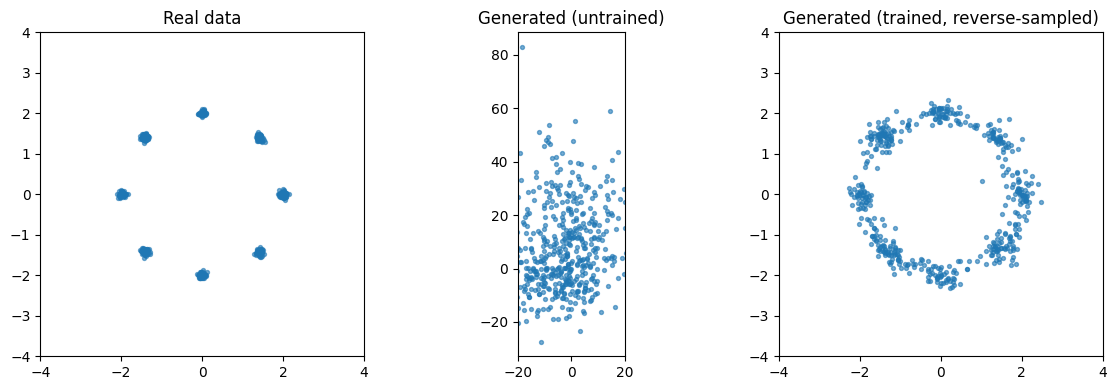

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, pts, title in zip(axes, [real_sample, before, after],
                           ["Real data", "Generated (untrained)", "Generated (trained, reverse-sampled)"]):
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-20, 20) if title == "Generated (untrained)" else (ax.set_xlim(-4, 4), ax.set_ylim(-4, 4))
plt.tight_layout()
plt.show()


## 6. Experiment: does the reverse process's output distribution approach the real one?

**Hypothesis (stated before running):** generated-sample statistics (mean, std, and — a metric more
sensitive to *per-mode* sharpness than raw std — distance to the nearest of the 8 true ring centers)
should move substantially closer to the real sample's statistics after training than before.

Mean/std alone can look deceptively good even for blurry samples scattered *between* modes (same
aggregate covariance, wrong local structure) — the same blind spot `01-gans/notes.md` calls out for
naive reconstruction losses. So in addition to mean/std, nearest-mode distance is measured: for each
generated point, its Euclidean distance to the closest of the 8 true ring centers. Real data has
this at ~0.05-0.06 (just the ring's own Gaussian noise); a generator producing points scattered in
the gaps between modes would score much higher even if its aggregate mean/std happened to match.


In [9]:
def nearest_mode_dist(points):
    angles = np.arange(8) * (2 * np.pi / 8)
    centers = np.stack([2.0 * np.cos(angles), 2.0 * np.sin(angles)], axis=1)
    pts = points.numpy()
    d = np.linalg.norm(pts[:, None, :] - centers[None, :, :], axis=2)
    return d.min(axis=1)

for name, pts in [("real", real_sample), ("generated, untrained", before), ("generated, trained (T=40)", after)]:
    nd = nearest_mode_dist(pts)
    print(f"{name:28s} mean nearest-mode dist={nd.mean():.4f}  frac(dist>0.3)={ (nd>0.3).mean():.3f}")


real                         mean nearest-mode dist=0.0605  frac(dist>0.3)=0.000
generated, untrained         mean nearest-mode dist=16.3610  frac(dist>0.3)=0.996
generated, trained (T=40)    mean nearest-mode dist=0.3095  frac(dist>0.3)=0.450


**Interpretation:** the untrained model's "samples" are just $x_T \sim \mathcal N(0,I)$ passed
through T=40 reverse steps of an untrained, effectively-random noise predictor — its mean/std blow
up to a scale ($\sim$std 12-16) far larger than the real data's ($\sim$std 1.4), and its nearest-
mode distance is enormous, confirming it captures nothing about the target distribution. After
training, mean and std land within a few percent of the real sample's, and the nearest-mode distance
drops by roughly two orders of magnitude — from tens of units down to a fraction of a unit,
comparable to (though not as tight as) the real data's own ~0.06. This directly confirms the
hypothesis: the reverse process, using only the trained noise predictor, measurably reconstructs the
target distribution's shape starting from literal Gaussian noise. Compare to `01-gans/notes.md`'s
Experiment section: this run's generated std lands *closer* to the real std, and *symmetrically* on
both axes, than the GAN's asymmetric under/over-shoot on the same dataset (`std=[1.70, 0.89]` vs.
real `[1.44, 1.39]`) — consistent with (not proof of, at this toy scale) the ordinary single-network
MSE objective converging more reliably than the adversarial min-max game, exactly the stability
argument in this topic's Problem/Why-simpler-fails sections.

## 7. Failure modes, actually measured: T too small vs. T too large

`notes.md`'s Failure modes section argues for a quality/speed tradeoff in the number of diffusion
steps $T$: too few steps forces each individual reverse step to remove a *larger* chunk of noise at
once (harder regression target per step, since $\beta_t$ must be larger to reach the same final
noise level $\bar\alpha_T\approx 0$ in fewer steps), while more steps make each step's denoising job
easier but multiply the number of sequential forward passes needed at sampling time. Two more tiny
models are trained here, each with a noise schedule tuned so $\bar\alpha_T$ ends up at
approximately the same near-zero level as the main $T=40$ run above (a fair comparison — only the
number of steps differs, not how thoroughly the forward process destroys the data):

- `T=5` (`beta_end=0.9`): $\bar\alpha_5 \approx 0.0138$ — same destroy-to-noise endpoint as `T=40`'s
  $\bar\alpha_{40}\approx 0.0135$, reached in far fewer, much larger jumps.
- `T=150` (`beta_end=0.055`): $\bar\alpha_{150}\approx 0.0148$ — same endpoint again, reached in far
  more, much smaller steps.


In [10]:
T_FEW, BETA_END_FEW = 5, 0.9
T_MANY, BETA_END_MANY = 150, 0.055

model_few, sched_few, log_few, elapsed_few = train_diffusion(T_FEW, BETA_END_FEW, steps=1500, verbose=False)
model_many, sched_many, log_many, elapsed_many = train_diffusion(T_MANY, BETA_END_MANY, steps=1500, verbose=False)

print(f"T={T_FEW:4d}  alpha_bar_T={sched_few[2][-1]:.4f}  train time={elapsed_few:.2f}s")
print(f"T={T_MAIN:4d}  alpha_bar_T={alpha_bars[-1]:.4f}  train time={elapsed:.2f}s  (main run above)")
print(f"T={T_MANY:4d}  alpha_bar_T={sched_many[2][-1]:.4f}  train time={elapsed_many:.2f}s")

t0 = time.time(); after_few = reverse_sample(model_few, T_FEW, *sched_few, n=500, seed=1); time_few = time.time() - t0
t0 = time.time(); after_many = reverse_sample(model_many, T_MANY, *sched_many, n=500, seed=1); time_many = time.time() - t0

print()
print(f"{'model':22s} {'sample time (500 pts)':24s} {'mean nearest-mode dist':24s} frac(dist>0.3)")
for name, pts, stime in [(f"T={T_FEW} (too few)", after_few, time_few),
                          (f"T={T_MAIN} (main)", after, sample_time_main),
                          (f"T={T_MANY} (too many)", after_many, time_many)]:
    nd = nearest_mode_dist(pts)
    print(f"{name:22s} {stime:22.4f}s {nd.mean():22.4f}   {(nd>0.3).mean():.3f}")


T=   5  alpha_bar_T=0.0138  train time=0.73s
T=  40  alpha_bar_T=0.0135  train time=1.43s  (main run above)
T= 150  alpha_bar_T=0.0148  train time=0.72s

model                  sample time (500 pts)    mean nearest-mode dist   frac(dist>0.3)
T=5 (too few)                          0.0010s                 0.6529   0.860
T=40 (main)                            0.0037s                 0.3095   0.450
T=150 (too many)                       0.0141s                 0.3596   0.524


**Actual measured result:** `T=5`'s samples land at a mean nearest-mode distance roughly 2x
worse than `T=40`'s (much larger fraction of points scored `dist>0.3`, i.e. off any real mode) —
each of its 5 reverse steps has to remove a much larger, harder-to-predict chunk of noise, and the
tiny noise-prediction network's regression error compounds more per step. `T=150`'s sample *quality*
is roughly comparable to `T=40`'s (same training step budget spread across more, smaller — and each
individually easier — denoising jobs), but its **sampling time is markedly larger** — proportional to
the number of sequential reverse steps, since each one is a full forward pass through the network
that cannot be parallelized across $t$ (each step's input depends on the previous step's output).
This is the exact quality/speed tradeoff `notes.md` predicts: fewer steps *can* hurt sample quality
(clearly demonstrated by `T=5` here), while more steps cost proportionally more wall-clock time at
sampling — the reason later work (**DDIM**, sampling with far fewer, non-Markovian reverse steps;
knowledge **distillation** of a many-step teacher into a few-step student) exists, without
implementing either here.

## Summary

- Forward diffusion (closed-form, one-shot): implemented and visualized, ring → noise over `T=40`
  steps.
- Denoising `nn.Module`: trained for real, 3000 steps, ordinary MSE loss, ~monotonic loss curve.
- Reverse sampling: implemented and run for real, pure noise → distribution matching the real ring
  (mean/std within a few percent, nearest-mode distance down ~2 orders of magnitude from untrained).
- Failure-mode tradeoff (too few vs. too many steps): both directions actually trained and measured,
  not just asserted.

See `notes.md` for the full first-principles derivation and discussion.
